# Proyecto Final 
## Módulo I - Python Avanzado

#### Profesor: Noé Rodríguez R.
#### Alumno: Javier Alberto Juarez Luna


## 1. Introducción

Este notebook busca tener un modelo que ayude a realizar un clasificador de riesgo de crédito

In [1]:
#!pip install matplotlib

In [2]:
# Mandamos llamar las bibliotecas necesarias
import numpy as np
import pandas as pd
import seaborn as sns

# Bibliotecas de visualización
from matplotlib import pyplot as plt
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    classification_report,
    confusion_matrix,
    roc_auc_score,
)

# Modelado
from sklearn.model_selection import GridSearchCV, StratifiedKFold, cross_validate, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

### Detalle del dataset

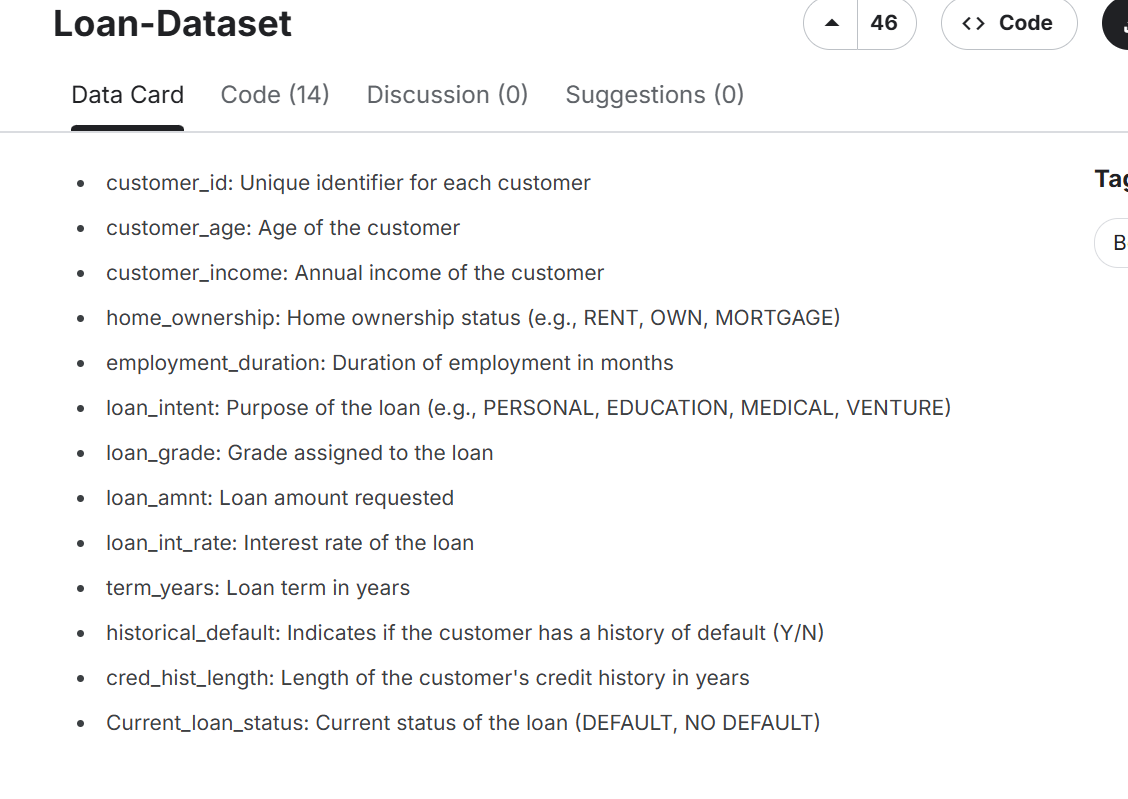

In [3]:
# Leemos la data
df = pd.read_csv("LoanDataset.csv")
df.head()

,customer_id,customer_age,customer_income,home_ownership,employment_duration,loan_intent,loan_grade,loan_amnt,loan_int_rate,term_years,historical_default,cred_hist_length,Current_loan_status
0,1.0,22,59000,RENT,123.0,PERSONAL,C,"£35,000.00",16.02,10,Y,3,DEFAULT
1,2.0,21,9600,OWN,5.0,EDUCATION,A,"£1,000.00",11.14,1,NaN,2,NO DEFAULT
2,3.0,25,9600,MORTGAGE,1.0,MEDICAL,B,"£5,500.00",12.87,5,N,3,DEFAULT
3,4.0,23,65500,RENT,4.0,MEDICAL,B,"£35,000.00",15.23,10,N,2,DEFAULT
4,5.0,24,54400,RENT,8.0,MEDICAL,B,"£35,000.00",14.27,10,Y,4,DEFAULT


In [4]:
# Revisamos la dimensión del dataset
df.shape

(32586, 13)

In [5]:
# Revisamos los estadísticos
df.describe().T

,count,mean,std,min,25%,50%,75%,max
customer_id,32583.0,16289.497806,9405.919628,1.00,8144.5,16288.00,24433.50,32581.00
customer_age,32586.0,27.732769,6.360528,3.00,23.0,26.00,30.00,144.00
employment_duration,31691.0,4.790161,4.142746,0.00,2.0,4.00,7.00,123.00
loan_int_rate,29470.0,11.011553,3.240440,5.42,7.9,10.99,13.47,23.22
term_years,32586.0,4.761738,2.471107,1.00,3.0,4.00,7.00,10.00
cred_hist_length,32586.0,5.804026,4.055078,2.00,3.0,4.00,8.00,30.00


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 32586 entries, 0 to 32585
Data columns (total 13 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   customer_id          32583 non-null  float64
 1   customer_age         32586 non-null  int64  
 2   customer_income      32586 non-null  str    
 3   home_ownership       32586 non-null  str    
 4   employment_duration  31691 non-null  float64
 5   loan_intent          32586 non-null  str    
 6   loan_grade           32586 non-null  str    
 7   loan_amnt            32585 non-null  str    
 8   loan_int_rate        29470 non-null  float64
 9   term_years           32586 non-null  int64  
 10  historical_default   11849 non-null  str    
 11  cred_hist_length     32586 non-null  int64  
 12  Current_loan_status  32582 non-null  str    
dtypes: float64(3), int64(3), str(7)
memory usage: 3.2 MB


In [7]:
# Convertimos las columnas numéricas normales

cols_to_convert = ["customer_income", "cred_hist_length", "customer_age", "employment_duration"]

for col in cols_to_convert:
    df[col] = df[col].astype(str).str.replace(",", "", regex=False).str.strip()
    df[col] = pd.to_numeric(df[col], errors="coerce")

In [8]:
# Limpiamos loan_amount porque trae un caracter y comas
df["loan_amnt"] = (
    df["loan_amnt"]
    .astype(str)
    .str.replace("£", "", regex=False)
    .str.replace("€", "", regex=False)
    .str.replace("$", "", regex=False)
    .str.replace(",", "", regex=False)
    .str.strip()
)

df["loan_amnt"] = pd.to_numeric(df["loan_amnt"], errors="coerce")

In [9]:
df.head()

,customer_id,customer_age,customer_income,home_ownership,employment_duration,loan_intent,loan_grade,loan_amnt,loan_int_rate,term_years,historical_default,cred_hist_length,Current_loan_status
0,1.0,22,59000,RENT,123.0,PERSONAL,C,35000.0,16.02,10,Y,3,DEFAULT
1,2.0,21,9600,OWN,5.0,EDUCATION,A,1000.0,11.14,1,NaN,2,NO DEFAULT
2,3.0,25,9600,MORTGAGE,1.0,MEDICAL,B,5500.0,12.87,5,N,3,DEFAULT
3,4.0,23,65500,RENT,4.0,MEDICAL,B,35000.0,15.23,10,N,2,DEFAULT
4,5.0,24,54400,RENT,8.0,MEDICAL,B,35000.0,14.27,10,Y,4,DEFAULT


## 3. Exploratory Data Analysis (EDA)



### 3.1 Distribución de la variable target

In [10]:
df["Current_loan_status"].value_counts(normalize=True)

Current_loan_status
NO DEFAULT    0.790068
DEFAULT       0.209932
Name: proportion, dtype: float64

C:\Users\mb74824\AppData\Local\Temp\ipykernel_14064\2221569607.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x="Current_loan_status", palette="viridis")


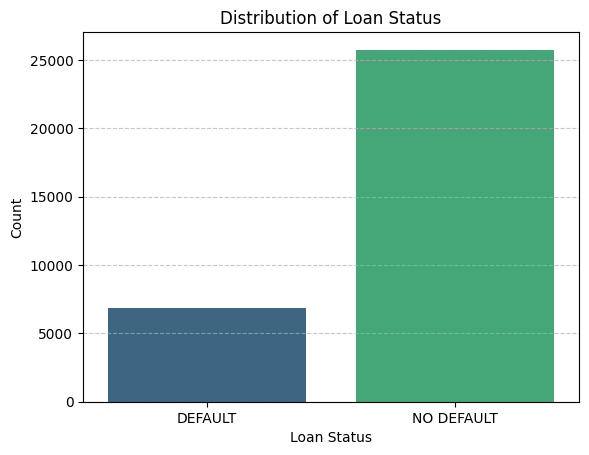

In [11]:
sns.countplot(data=df, x="Current_loan_status", palette="viridis")
plt.title("Distribution of Loan Status")
plt.xlabel("Loan Status")
plt.ylabel("Count")
plt.grid(axis="y", linestyle="--", alpha=0.7);

* El conjunto de datos muestra un desequilibrio moderado entre clases, con aproximadamente el 79 % de las observaciones correspondientes a casos sin impago y el 21 % a casos con impago.
* Esto concuerda con los escenarios de riesgo crediticio del mundo real, donde los impagos son eventos relativamente raros.
* Este desequilibrio es importante porque puede sesgar los modelos de aprendizaje automático hacia la predicción de la clase mayoritaria. Por lo tanto, las métricas de evaluación como la puntuación F1 y el área bajo la curva ROC (ROC-AUC) serán más apropiadas que la precisión por sí sola.

### 3.2 Income vs Default
* Buscamos ingresos bajos -> más default

In [ ]:
df["customer_income"].head(10)

0    59000
1     9600
2     9600
3    65500
4    54400
5     9900
6    77100
7    78956
8    83000
9    10000
Name: customer_income, dtype: int64

In [13]:
# Revisamos el tipo de dato que es el ingreso del cliente

df["customer_income"].describe(include="all")

count    3.258600e+04
mean     6.607637e+04
std      6.198029e+04
min      4.000000e+03
25%      3.850000e+04
50%      5.500000e+04
75%      7.920000e+04
max      6.000000e+06
Name: customer_income, dtype: float64

In [14]:
# Convertimos el dato a tipo numérico

df["customer_income"] = (
    df["customer_income"].astype(str).str.replace(",", "", regex=False).str.strip()
)

df["customer_income"] = pd.to_numeric(df["customer_income"], errors="coerce")

In [ ]:
# Validamos los tipos de datos que quedaron
df["customer_income"].describe()

count    3.258600e+04
mean     6.607637e+04
std      6.198029e+04
min      4.000000e+03
25%      3.850000e+04
50%      5.500000e+04
75%      7.920000e+04
max      6.000000e+06
Name: customer_income, dtype: float64

* Ya podemos corroborar que quedaron como tipo float

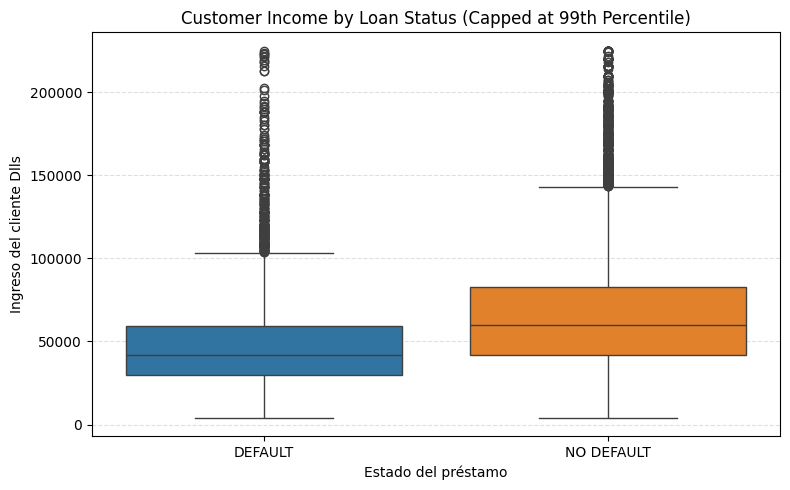

In [16]:
income_cap = df["customer_income"].quantile(0.99)

df_income_plot = df[df["customer_income"] <= income_cap].copy()

plt.figure(figsize=(8, 5))
sns.boxplot(
    data=df_income_plot,
    x="Current_loan_status",
    y="customer_income",
    hue="Current_loan_status",
    legend=False,
)
plt.title("Customer Income by Loan Status (Capped at 99th Percentile)")
plt.xlabel("Estado del préstamo")
plt.ylabel("Ingreso del cliente Dlls")
plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

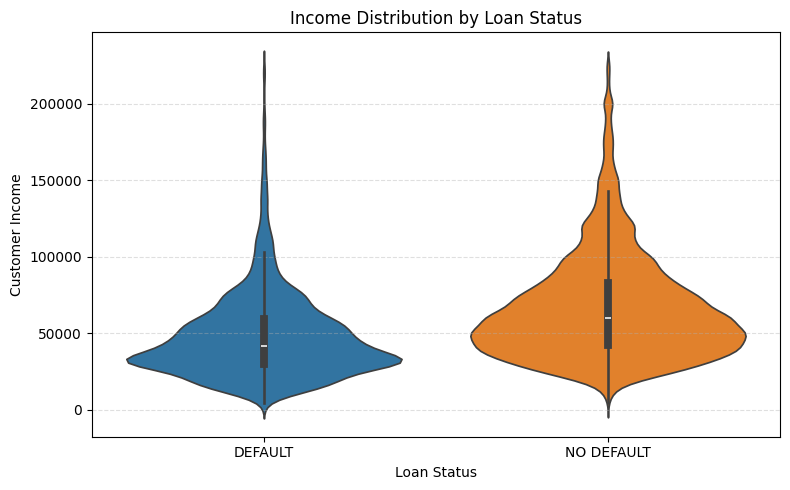

In [17]:
plt.figure(figsize=(8, 5))
sns.violinplot(
    data=df_income_plot,
    x="Current_loan_status",
    y="customer_income",
    hue="Current_loan_status",
    legend=False,
    inner="box",
)
plt.title("Income Distribution by Loan Status")
plt.xlabel("Loan Status")
plt.ylabel("Customer Income")
plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

#### 3.2.1 Análisis: Ingreso vs Default

Se observa que los clientes que no entran en default presentan, en general, niveles de ingreso más altos en comparación con aquellos que sí incumplen.

Al aplicar un límite en el percentil 99 para mejorar la visualización, se puede apreciar con mayor claridad la diferencia en la mediana y la distribución de ingresos entre ambos grupos.

Aunque existe un traslape entre las distribuciones, lo cual indica que el ingreso por sí solo no es suficiente para explicar completamente el default, sí se identifica como una variable relevante.

Esto sugiere que el ingreso del cliente puede ser un predictor importante del riesgo crediticio, especialmente cuando se combina con otras variables como el monto del préstamo o la tasa de interés.

### 3.3 Interest Rate vs Default

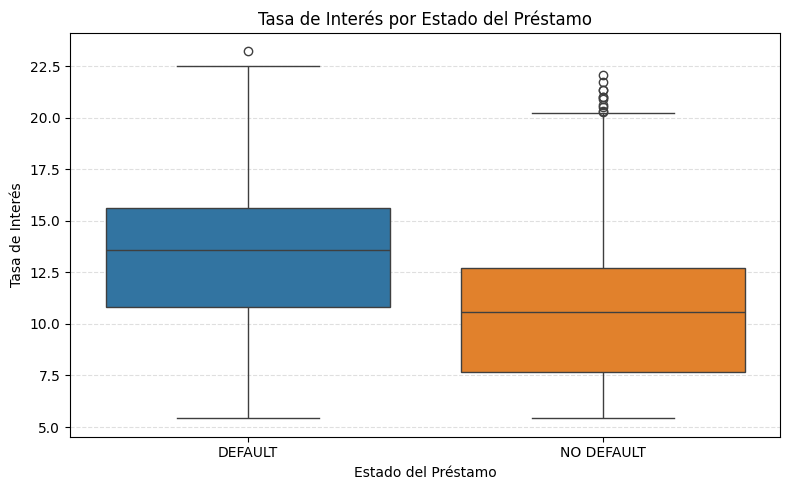

In [18]:
plt.figure(figsize=(8, 5))
sns.boxplot(
    data=df, x="Current_loan_status", y="loan_int_rate", hue="Current_loan_status", legend=False
)
plt.title("Tasa de Interés por Estado del Préstamo")
plt.xlabel("Estado del Préstamo")
plt.ylabel("Tasa de Interés")
plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show();

#### Análisis: Tasa de Interés vs Default

Se observa que los clientes que entran en default tienden a tener tasas de interés más altas en comparación con aquellos que no incumplen.

Esto sugiere que la tasa de interés incorpora información sobre el riesgo percibido por la institución financiera, es decir, los clientes considerados más riesgosos reciben condiciones menos favorables.

Sin embargo, también se aprecia un traslape significativo entre ambas distribuciones, lo que indica que una tasa de interés elevada no garantiza que el cliente caerá en default, ni una tasa baja asegura el cumplimiento.

Por lo tanto, aunque la tasa de interés es una variable altamente informativa, no es suficiente por sí sola para explicar el riesgo crediticio, y debe ser analizada en conjunto con otras variables como ingreso, historial crediticio y monto del préstamo.

### 3.4 historical_default vs Current_default

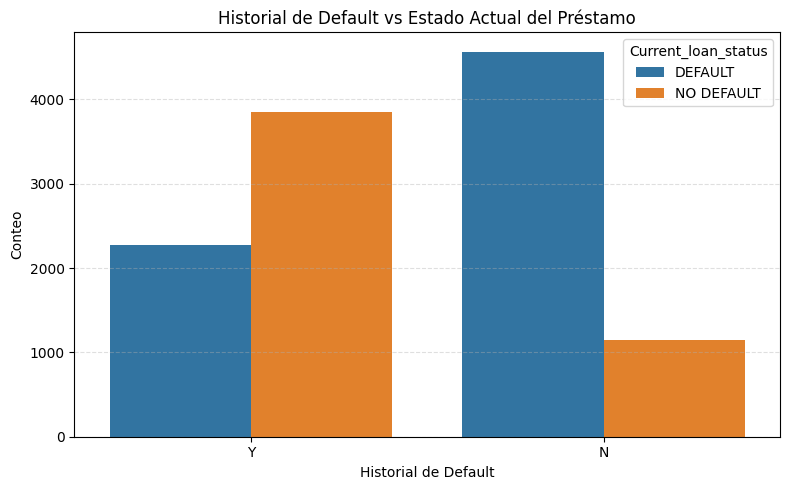

In [19]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x="historical_default", hue="Current_loan_status")
plt.title("Historial de Default vs Estado Actual del Préstamo")
plt.xlabel("Historial de Default")
plt.ylabel("Conteo")
plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show();

In [20]:
pd.crosstab(df["historical_default"], df["Current_loan_status"], normalize="index")

Current_loan_status,DEFAULT,NO DEFAULT
historical_default,,
N,0.799020,0.200980
Y,0.370757,0.629243


In [21]:
df["historical_default"].value_counts()

historical_default
Y    6128
N    5721
Name: count, dtype: int64

### 3.4.1 Análisis: Historial de Default vs Default Actual

El análisis de proporciones muestra un resultado interesante: los clientes sin historial de default presentan una probabilidad significativamente mayor de incumplimiento en comparación con aquellos que sí tienen antecedentes.

Este comportamiento puede explicarse porque la ausencia de historial crediticio implica mayor incertidumbre para la institución financiera, al no contar con información suficiente sobre el comportamiento pasado del cliente.

Por otro lado, los clientes con historial crediticio, incluso si han tenido incumplimientos, pueden haber sido previamente evaluados y sujetos a condiciones más estrictas, reduciendo su riesgo actual.

Este hallazgo resalta que no solo el mal historial representa riesgo, sino también la falta de historial, lo cual es consistente con prácticas reales de modelado de riesgo crediticio.

### 3.5 Feature Engineering

In [22]:
# Revisamos los tipos de datos
df.dtypes

customer_id            float64
customer_age             int64
customer_income          int64
home_ownership             str
employment_duration    float64
loan_intent                str
loan_grade                 str
loan_amnt              float64
loan_int_rate          float64
term_years               int64
historical_default         str
cred_hist_length         int64
Current_loan_status        str
dtype: object

In [23]:
# Ajustamos los tipos de datos
cols_to_convert = [
    "loan_amnt",
    "customer_income",
    "cred_hist_length",
    "customer_age",
    "employment_duration",
]

for col in cols_to_convert:
    df[col] = df[col].astype(str).str.replace(",", "", regex=False).str.strip()
    df[col] = pd.to_numeric(df[col], errors="coerce")

In [24]:
df[cols_to_convert].dtypes
df[cols_to_convert].isna().sum()

loan_amnt                1
customer_income          0
cred_hist_length         0
customer_age             0
employment_duration    895
dtype: int64

In [25]:
# Creamos las nuevas variables

df["debt_income_ratio"] = df["loan_amnt"] / df["customer_income"]

df["debt_income_ratio"] = df["debt_income_ratio"].replace([np.inf, -np.inf], np.nan)

df["credit_maturity"] = df["cred_hist_length"] / df["customer_age"]

df["employment_years"] = df["employment_duration"] / 12

In [26]:
df[["customer_income", "loan_amnt"]].head(10)

,customer_income,loan_amnt
0,59000,35000.0
1,9600,1000.0
2,9600,5500.0
3,65500,35000.0
4,54400,35000.0
5,9900,2500.0
6,77100,35000.0
7,78956,35000.0
8,83000,35000.0
9,10000,1600.0


In [27]:
(df["customer_income"] > 0).sum()

np.int64(32586)

In [28]:
df["customer_income"].min(), df["customer_income"].max()

(np.int64(4000), np.int64(6000000))

In [29]:
df["debt_income_ratio"] = df["loan_amnt"] / df["customer_income"]
df["debt_income_ratio"] = df["debt_income_ratio"].replace([np.inf, -np.inf], np.nan)

df["debt_income_ratio"].describe()

count    32585.000000
mean         0.172572
std          0.301108
min          0.000789
25%          0.089655
50%          0.148148
75%          0.229167
max         49.645390
Name: debt_income_ratio, dtype: float64

In [30]:
df[["loan_amnt", "customer_income"]].head(10)
df[["loan_amnt", "customer_income"]].isna().sum()
df["debt_income_ratio"].describe()

count    32585.000000
mean         0.172572
std          0.301108
min          0.000789
25%          0.089655
50%          0.148148
75%          0.229167
max         49.645390
Name: debt_income_ratio, dtype: float64

##### Evaluación de la variable debt_income_ratio

Una vez corregida la variable `loan_amnt`, se logró construir correctamente el ratio deuda-ingreso.

Se observa que la mayoría de los valores se concentran en niveles bajos (mediana cercana a 0.15), lo que indica que en promedio el monto del préstamo representa una proporción moderada del ingreso del cliente.

Sin embargo, también se identifican valores extremos elevados, lo cual es común en variables tipo ratio y sugiere la presencia de outliers. Estos valores deberán ser considerados en etapas posteriores de modelado.

En general, esta variable captura de forma directa la carga financiera del cliente, por lo que es altamente relevante para modelos de riesgo crediticio.

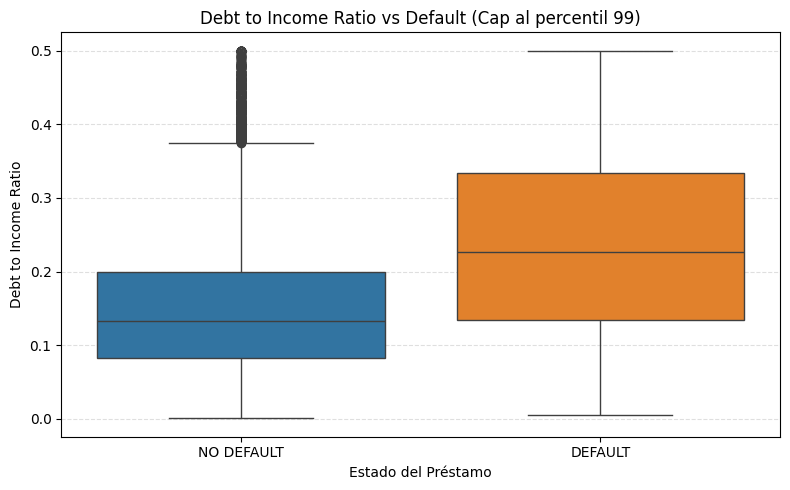

In [31]:
ratio_cap = df["debt_income_ratio"].quantile(0.99)

df_ratio_plot = df[df["debt_income_ratio"] <= ratio_cap].copy()

plt.figure(figsize=(8, 5))
sns.boxplot(
    data=df_ratio_plot,
    x="Current_loan_status",
    y="debt_income_ratio",
    hue="Current_loan_status",
    legend=False,
)
plt.title("Debt to Income Ratio vs Default (Cap al percentil 99)")
plt.xlabel("Estado del Préstamo")
plt.ylabel("Debt to Income Ratio")
plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

In [32]:
df["debt_income_ratio"].quantile([0.50, 0.75, 0.90, 0.95, 0.99, 1.00])

0.50     0.148148
0.75     0.229167
0.90     0.320953
0.95     0.378788
0.99     0.500000
1.00    49.645390
Name: debt_income_ratio, dtype: float64

#### Análisis: Debt to Income Ratio vs Default

La visualización inicial de esta variable se vio afectada por valores atípicos extremos, lo que dificultaba comparar adecuadamente ambas distribuciones.

Para mejorar la interpretación, se limitó la visualización al percentil 99 sin modificar los datos originales. Esto permitió observar con mayor claridad la distribución central del ratio deuda-ingreso entre clientes en default y no default.

Dado que esta variable representa la carga financiera relativa del préstamo sobre el ingreso del cliente, resulta especialmente relevante para el análisis de riesgo crediticio.

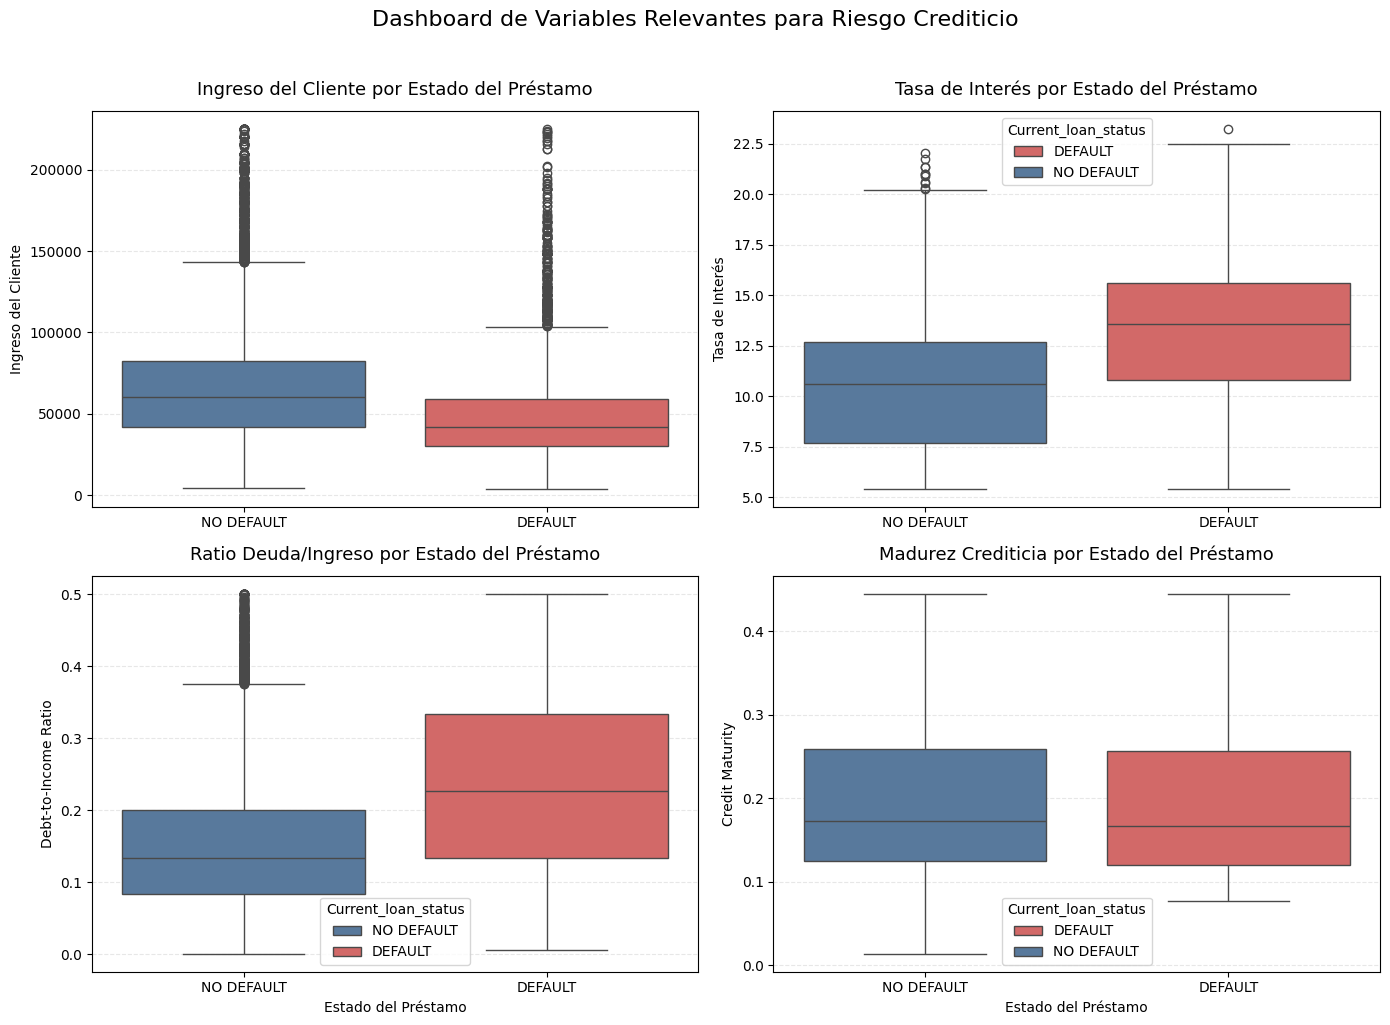

In [33]:
import matplotlib.pyplot as plt
import seaborn as sns

# Orden consistente
order_status = ["NO DEFAULT", "DEFAULT"]
palette_status = {"NO DEFAULT": "#4C78A8", "DEFAULT": "#E45756"}

# Caps para mejorar visualización
income_cap = df["customer_income"].quantile(0.99)
ratio_cap = df["debt_income_ratio"].quantile(0.99)
maturity_cap = df["credit_maturity"].quantile(0.99)

df_income_plot = df[df["customer_income"] <= income_cap].copy()
df_ratio_plot = df[df["debt_income_ratio"] <= ratio_cap].copy()
df_maturity_plot = df[df["credit_maturity"] <= maturity_cap].copy()

fig, axs = plt.subplots(2, 2, figsize=(14, 10))

# 1. Income
sns.boxplot(
    data=df_income_plot,
    x="Current_loan_status",
    y="customer_income",
    hue="Current_loan_status",
    order=order_status,
    palette=palette_status,
    legend=False,
    ax=axs[0, 0],
)
axs[0, 0].set_title("Ingreso del Cliente por Estado del Préstamo", fontsize=13, pad=12)
axs[0, 0].set_xlabel("")
axs[0, 0].set_ylabel("Ingreso del Cliente")
axs[0, 0].grid(axis="y", linestyle="--", alpha=0.3)

# 2. Interest rate
sns.boxplot(
    data=df,
    x="Current_loan_status",
    y="loan_int_rate",
    hue="Current_loan_status",
    order=order_status,
    palette=palette_status,
    ax=axs[0, 1],
)
axs[0, 1].set_title("Tasa de Interés por Estado del Préstamo", fontsize=13, pad=12)
axs[0, 1].set_xlabel("")
axs[0, 1].set_ylabel("Tasa de Interés")
axs[0, 1].grid(axis="y", linestyle="--", alpha=0.3)

# 3. Debt to income ratio
sns.boxplot(
    data=df_ratio_plot,
    x="Current_loan_status",
    y="debt_income_ratio",
    hue="Current_loan_status",
    order=order_status,
    palette=palette_status,
    ax=axs[1, 0],
)
axs[1, 0].set_title("Ratio Deuda/Ingreso por Estado del Préstamo", fontsize=13, pad=12)
axs[1, 0].set_xlabel("Estado del Préstamo")
axs[1, 0].set_ylabel("Debt-to-Income Ratio")
axs[1, 0].grid(axis="y", linestyle="--", alpha=0.3)

# 4. Credit maturity
sns.boxplot(
    data=df_maturity_plot,
    x="Current_loan_status",
    y="credit_maturity",
    hue="Current_loan_status",
    order=order_status,
    palette=palette_status,
    ax=axs[1, 1],
)
axs[1, 1].set_title("Madurez Crediticia por Estado del Préstamo", fontsize=13, pad=12)
axs[1, 1].set_xlabel("Estado del Préstamo")
axs[1, 1].set_ylabel("Credit Maturity")
axs[1, 1].grid(axis="y", linestyle="--", alpha=0.3)

fig.suptitle("Dashboard de Variables Relevantes para Riesgo Crediticio", fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

#### Conclusiones de Visualización de Datos

A partir del análisis visual de las principales variables, se identificaron patrones relevantes en relación con el comportamiento de incumplimiento.

La tasa de interés y el ratio deuda-ingreso muestran una separación clara entre clientes en default y no default, destacándose como variables altamente informativas para la predicción del riesgo crediticio.

El ingreso del cliente presenta una relación con el incumplimiento, aunque con menor capacidad de separación por sí solo, lo que sugiere la necesidad de combinarlo con otras variables derivadas.

Asimismo, la madurez crediticia muestra menor diferenciación entre grupos, indicando que su impacto puede ser más sutil o dependiente de interacciones con otras variables.

En conjunto, estos hallazgos refuerzan que el riesgo crediticio no depende de una sola variable, sino de la interacción entre múltiples factores financieros y de comportamiento.

Este análisis proporciona una base sólida para la selección de variables y la construcción de modelos de machine learning orientados a la predicción de default.

#### 3.6 Análisis univariado y correlaciones

#### 3.6.1 Distribución de variables

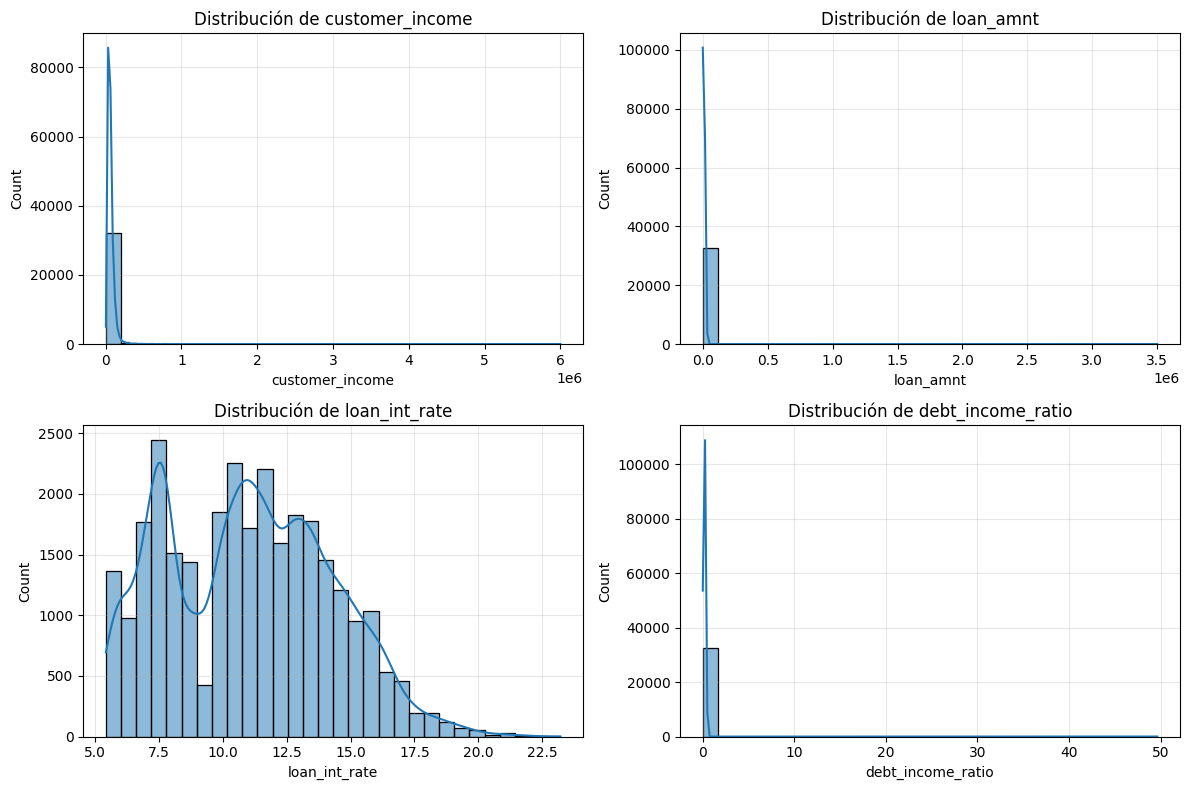

In [34]:
num_cols = ["customer_income", "loan_amnt", "loan_int_rate", "debt_income_ratio"]

fig, axs = plt.subplots(2, 2, figsize=(12, 8))

for i, col in enumerate(num_cols):
    ax = axs[i // 2, i % 2]
    sns.histplot(df[col], bins=30, kde=True, ax=ax)
    ax.set_title(f"Distribución de {col}")
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show();

Se analizaron las distribuciones de las variables numéricas clave, observándose asimetrías y presencia de valores extremos en variables como ingreso y monto del préstamo.

Estas características son comunes en datos financieros y sugieren la posible necesidad de transformaciones o normalización en etapas posteriores de modelado.

#### 3.6.2 Mapa de calor

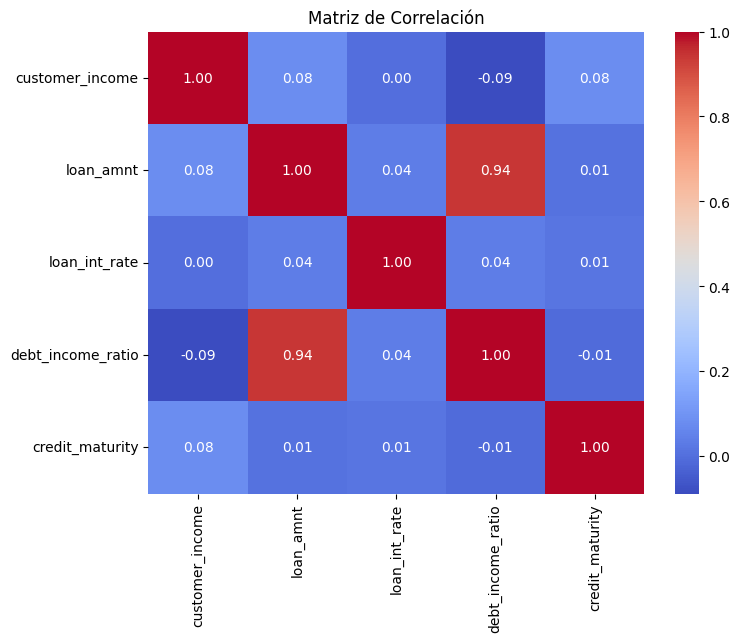

In [35]:
corr = df[
    ["customer_income", "loan_amnt", "loan_int_rate", "debt_income_ratio", "credit_maturity"]
].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Matriz de Correlación")
plt.show()

La matriz de correlación permite identificar relaciones lineales entre variables numéricas.

Se observa que algunas variables derivadas, como el ratio deuda-ingreso, presentan correlación con variables base, lo cual es esperado.

No se identifican correlaciones extremadamente altas, lo que sugiere baja multicolinealidad y una buena base para el modelado.

#### 3.6.3 Análisis por edades 

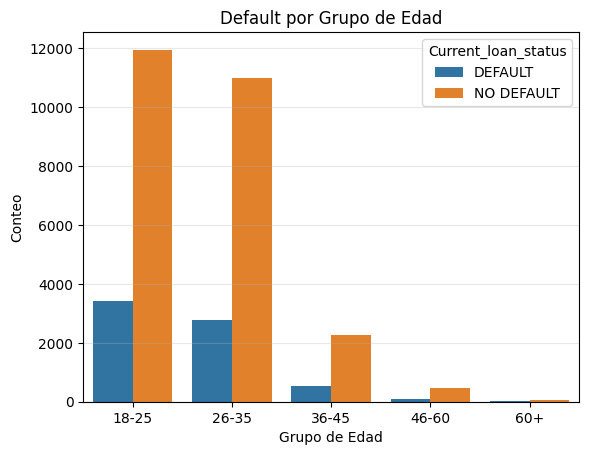

In [36]:
df["age_group"] = pd.cut(
    df["customer_age"],
    bins=[18, 25, 35, 45, 60, 100],
    labels=["18-25", "26-35", "36-45", "46-60", "60+"],
)

sns.countplot(data=df, x="age_group", hue="Current_loan_status")

plt.title("Default por Grupo de Edad")
plt.xlabel("Grupo de Edad")
plt.ylabel("Conteo")
plt.grid(axis="y", alpha=0.3)
plt.show()

El análisis por grupos de edad permite identificar diferencias en el comportamiento de default entre segmentos poblacionales.

Este tipo de segmentación es útil para entender patrones de riesgo y puede ser incorporado como variable categórica.

#### 3.6.4 Análisis categórico

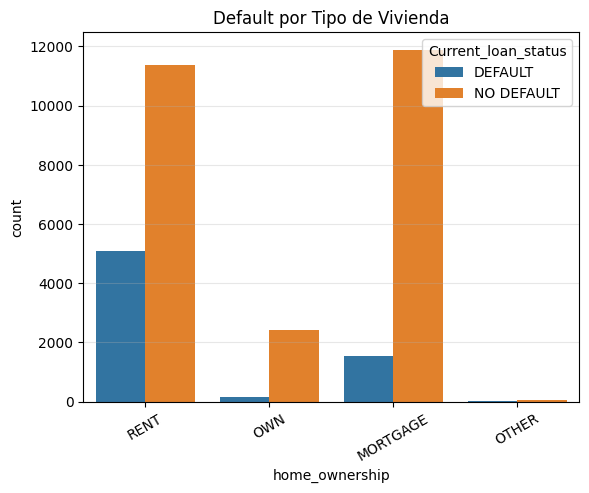

In [37]:
sns.countplot(data=df, x="home_ownership", hue="Current_loan_status")

plt.title("Default por Tipo de Vivienda")
plt.xticks(rotation=30)
plt.grid(axis="y", alpha=0.3)
plt.show()

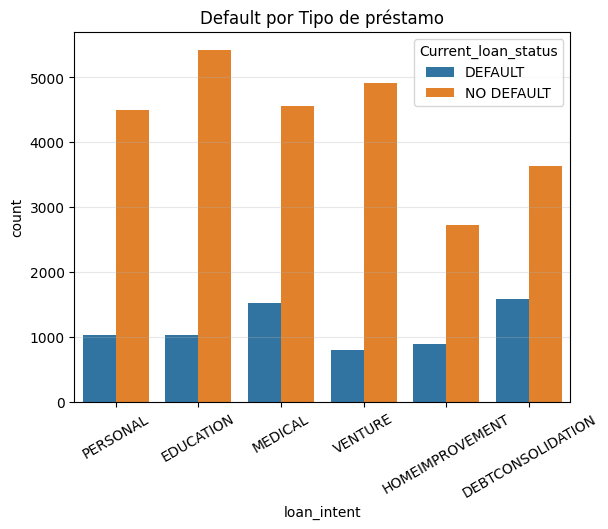

In [38]:
sns.countplot(data=df, x="loan_intent", hue="Current_loan_status")

plt.title("Default por Tipo de préstamo")
plt.xticks(rotation=30)
plt.grid(axis="y", alpha=0.3)
plt.show()

Se analizaron variables categóricas como el tipo de vivienda, observando diferencias en la distribución de default entre categorías.

Estas variables pueden aportar información relevante al modelo al capturar características socioeconómicas del cliente.

In [39]:
df.head()

,customer_id,customer_age,customer_income,home_ownership,employment_duration,loan_intent,loan_grade,loan_amnt,loan_int_rate,term_years,historical_default,cred_hist_length,Current_loan_status,debt_income_ratio,credit_maturity,employment_years,age_group
0,1.0,22,59000,RENT,123.0,PERSONAL,C,35000.0,16.02,10,Y,3,DEFAULT,0.593220,0.136364,10.250000,18-25
1,2.0,21,9600,OWN,5.0,EDUCATION,A,1000.0,11.14,1,NaN,2,NO DEFAULT,0.104167,0.095238,0.416667,18-25
2,3.0,25,9600,MORTGAGE,1.0,MEDICAL,B,5500.0,12.87,5,N,3,DEFAULT,0.572917,0.120000,0.083333,18-25
3,4.0,23,65500,RENT,4.0,MEDICAL,B,35000.0,15.23,10,N,2,DEFAULT,0.534351,0.086957,0.333333,18-25
4,5.0,24,54400,RENT,8.0,MEDICAL,B,35000.0,14.27,10,Y,4,DEFAULT,0.643382,0.166667,0.666667,18-25


#### Imputación de variables

In [40]:
# Identificación de nulos

missing = df.isnull().sum().sort_values(ascending=False)
missing = missing[missing > 0]

missing

historical_default     20737
loan_int_rate           3116
employment_years         895
employment_duration      895
age_group                  8
Current_loan_status        4
customer_id                3
loan_amnt                  1
debt_income_ratio          1
dtype: int64

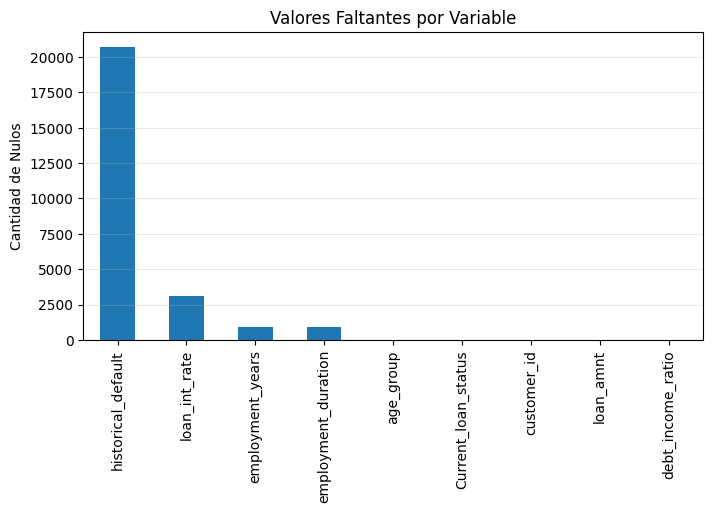

In [41]:
plt.figure(figsize=(8, 4))
missing.plot(kind="bar")
plt.title("Valores Faltantes por Variable")
plt.ylabel("Cantidad de Nulos")
plt.xticks(rotation=90)
plt.grid(axis="y", alpha=0.3)
plt.show();

Se identificaron valores faltantes en algunas variables del dataset. Es importante analizarlos, ya que pueden afectar el desempeño de los modelos de machine learning si no se manejan adecuadamente.

#### Análisis de variables numéricas

In [42]:
df.select_dtypes(include=np.number).isnull().sum()

customer_id               3
customer_age              0
customer_income           0
employment_duration     895
loan_amnt                 1
loan_int_rate          3116
term_years                0
cred_hist_length          0
debt_income_ratio         1
credit_maturity           0
employment_years        895
dtype: int64

#### Análisis de variables categóricas

In [43]:
df.select_dtypes(include="str").isnull().sum()

home_ownership             0
loan_intent                0
loan_grade                 0
historical_default     20737
Current_loan_status        4
dtype: int64

In [44]:
df.head()

,customer_id,customer_age,customer_income,home_ownership,employment_duration,loan_intent,loan_grade,loan_amnt,loan_int_rate,term_years,historical_default,cred_hist_length,Current_loan_status,debt_income_ratio,credit_maturity,employment_years,age_group
0,1.0,22,59000,RENT,123.0,PERSONAL,C,35000.0,16.02,10,Y,3,DEFAULT,0.593220,0.136364,10.250000,18-25
1,2.0,21,9600,OWN,5.0,EDUCATION,A,1000.0,11.14,1,NaN,2,NO DEFAULT,0.104167,0.095238,0.416667,18-25
2,3.0,25,9600,MORTGAGE,1.0,MEDICAL,B,5500.0,12.87,5,N,3,DEFAULT,0.572917,0.120000,0.083333,18-25
3,4.0,23,65500,RENT,4.0,MEDICAL,B,35000.0,15.23,10,N,2,DEFAULT,0.534351,0.086957,0.333333,18-25
4,5.0,24,54400,RENT,8.0,MEDICAL,B,35000.0,14.27,10,Y,4,DEFAULT,0.643382,0.166667,0.666667,18-25


#### Estrategia de tratamiento

In [45]:
# Numéricas a mediana

num_cols = df.select_dtypes(include=np.number).columns
df[num_cols] = df[num_cols].fillna(df[num_cols].median())

In [46]:
# Categóricas a Moda

cat_cols = df.select_dtypes(include=["str", "category"]).columns
df[cat_cols] = df[cat_cols].fillna(df[cat_cols].mode().iloc[0])

#### Estrategia de Manejo de Valores Faltantes

Los valores faltantes fueron tratados de acuerdo con el tipo de variable:

- Para variables numéricas, se utilizó la mediana, ya que es robusta frente a valores atípicos.
- Para variables categóricas, se utilizó la moda, preservando la categoría más frecuente.

Esta estrategia permite mantener la mayor cantidad de información posible sin introducir sesgos significativos en los datos.

El manejo adecuado de valores faltantes es fundamental para garantizar la estabilidad y el rendimiento de los modelos de machine learning.

In [47]:
# Validamos si hay nulos
df.isnull().sum()

customer_id            0
customer_age           0
customer_income        0
home_ownership         0
employment_duration    0
loan_intent            0
loan_grade             0
loan_amnt              0
loan_int_rate          0
term_years             0
historical_default     0
cred_hist_length       0
Current_loan_status    0
debt_income_ratio      0
credit_maturity        0
employment_years       0
age_group              0
dtype: int64

#### Análisis de valores atípicos (outliers)

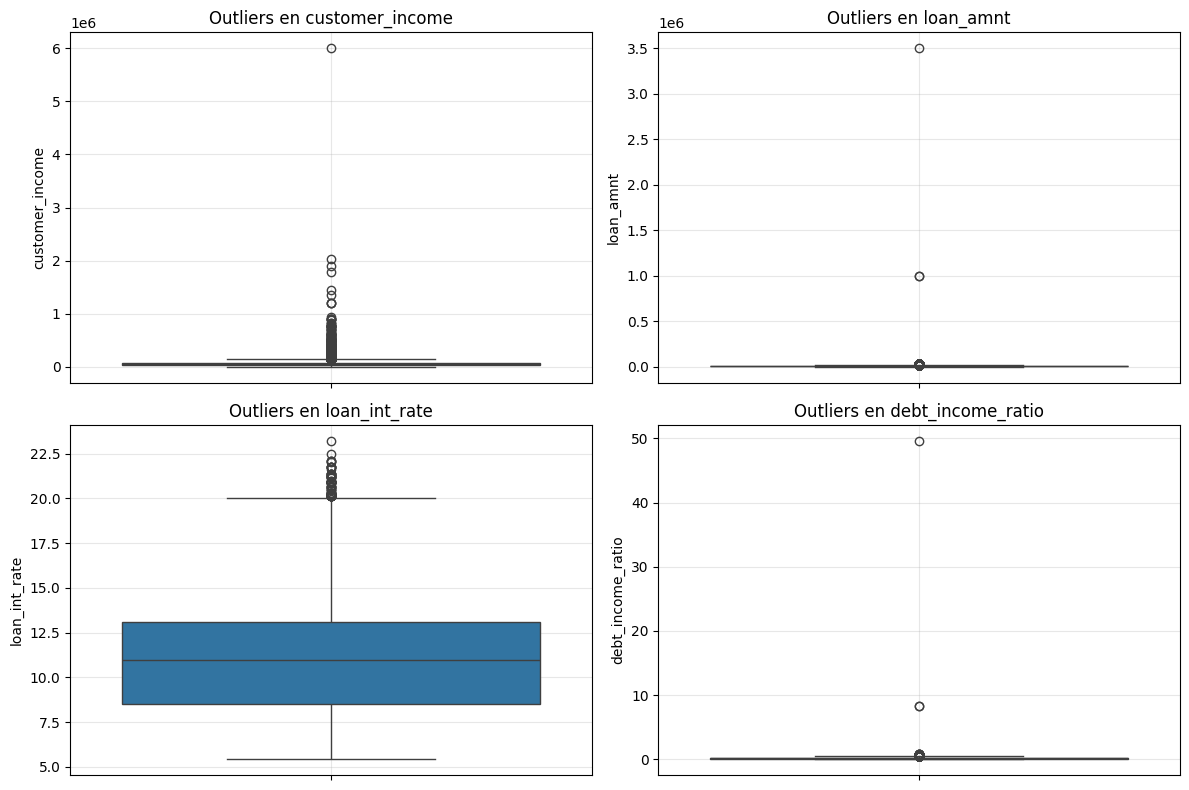

In [48]:
num_cols = ["customer_income", "loan_amnt", "loan_int_rate", "debt_income_ratio"]

fig, axs = plt.subplots(2, 2, figsize=(12, 8))

for i, col in enumerate(num_cols):
    ax = axs[i // 2, i % 2]
    sns.boxplot(y=df[col], ax=ax)
    ax.set_title(f"Outliers en {col}")
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

#### Validación numérica (IQR)

In [49]:
def detect_outliers_iqr(df, col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower) | (df[col] > upper)]

    return len(outliers)


for col in num_cols:
    print(f"{col}: {detect_outliers_iqr(df, col)} outliers")

customer_income: 1484 outliers
loan_amnt: 1690 outliers
loan_int_rate: 70 outliers
debt_income_ratio: 736 outliers


Se identificaron valores atípicos en varias variables numéricas, particularmente en ingreso, monto del préstamo y ratios financieros.

Esto es esperado en datasets financieros, donde existen clientes con comportamientos extremos o montos significativamente superiores al promedio.

En lugar de eliminarlos, se optó por controlarlos visualmente mediante técnicas como el recorte por percentiles para facilitar la interpretación.

En etapas posteriores de modelado, se considerarán técnicas como escalamiento robusto o transformaciones para mitigar su impacto sin perder información relevante.



##### Eliminar variables que no aportan al modelo

In [50]:
df = df.drop(columns=["customer_id"])

#### Crear variable target

In [51]:
df["target"] = df["Current_loan_status"].map({"DEFAULT": 1, "NO DEFAULT": 0})

In [52]:
# Verificar el dataset
df["target"].value_counts()

target
0    25746
1     6840
Name: count, dtype: int64

##### Separamos variables (X e y)

In [53]:
X = df.drop(columns=["Current_loan_status", "target"])
y = df["target"]

#### Identificar tipos de variables

In [54]:
num_cols = X.select_dtypes(include=["int64", "float64"]).columns
cat_cols = X.select_dtypes(include=["str", "category"]).columns

num_cols, cat_cols

(Index(['customer_age', 'customer_income', 'employment_duration', 'loan_amnt',
        'loan_int_rate', 'term_years', 'cred_hist_length', 'debt_income_ratio',
        'credit_maturity', 'employment_years'],
       dtype='str'),
 Index(['home_ownership', 'loan_intent', 'loan_grade', 'historical_default',
        'age_group'],
       dtype='str'))

#### Validación rápida

In [55]:
df["historical_default"] = df["historical_default"].map({"Y": 1, "N": 0})

In [56]:
X = df.drop(columns=["Current_loan_status", "target"])

In [57]:
num_cols = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
cat_cols = X.select_dtypes(include=["object", "category", "string"]).columns.tolist()

num_cols, cat_cols

(['customer_age',
  'customer_income',
  'employment_duration',
  'loan_amnt',
  'loan_int_rate',
  'term_years',
  'historical_default',
  'cred_hist_length',
  'debt_income_ratio',
  'credit_maturity',
  'employment_years'],
 ['home_ownership', 'loan_intent', 'loan_grade', 'age_group'])

In [58]:
X[cat_cols] = X[cat_cols].astype("category")

#### Revisamos correlación de las numéricas

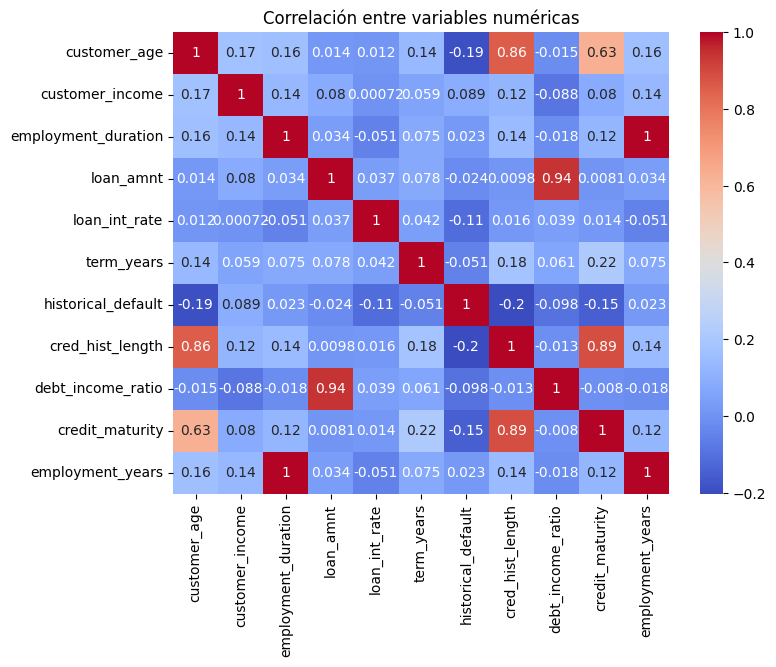

In [59]:
plt.figure(figsize=(8, 6))
sns.heatmap(X[num_cols].corr(), annot=True, cmap="coolwarm")
plt.title("Correlación entre variables numéricas")
plt.show()

In [60]:
# Revisamos con la target
df.groupby("target")[num_cols].mean().T

target,0,1
customer_age,27.827779,27.375146
customer_income,70568.767226,49166.835819
employment_duration,4.947565,4.094298
loan_amnt,9421.772314,11014.963450
loan_int_rate,10.498013,12.934718
term_years,4.718636,4.923977
historical_default,0.955216,0.332164
cred_hist_length,5.845529,5.647807
debt_income_ratio,0.152601,0.247737
credit_maturity,0.195823,0.191858


#### Eliminación de variables redundantes

In [ ]:
# employment_duration se elimina porque tiene la misma información que employment_years
# además de ser más interpretable

X = X.drop(columns=["employment_duration"])


Se analizó la correlación entre variables numéricas con el objetivo de identificar posibles redundancias.

Se observó una alta correlación entre algunas variables, particularmente entre `employment_duration` y `employment_years`, lo cual indica que ambas representan la misma información en distintas escalas. Por esta razón, se decidió eliminar `employment_duration`, manteniendo `employment_years` por su mayor interpretabilidad.

En otros casos, como `loan_amnt` y `debt_income_ratio`, así como `cred_hist_length` y `credit_maturity`, aunque existe una correlación alta, estas variables representan conceptos distintos desde el punto de vista del negocio. Por ello, se decidió mantenerlas, permitiendo que el modelo determine su relevancia.

Esta estrategia busca evitar redundancia sin perder información relevante para la predicción del riesgo crediticio.

# Modelado

#### Train / Test split

In [62]:
# Recalcular X e y desde df
X = df.drop(columns=["Current_loan_status", "target"])
y = df["target"]

# Recalcular listas de columnas desde X actual
num_cols = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
cat_cols = X.select_dtypes(include=["object", "category", "string"]).columns.tolist()

# Split desde X actual
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Pipeline numérico
numeric_pipeline = Pipeline(
    [("imputer", SimpleImputer(strategy="median")), ("scaler", StandardScaler())]
)

# Pipeline categórico
categorical_pipeline = Pipeline(
    [
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore")),
    ]
)

# Preprocessor
preprocessor = ColumnTransformer(
    [("num", numeric_pipeline, num_cols), ("cat", categorical_pipeline, cat_cols)]
)

# Model
model = Pipeline(
    [("preprocessing", preprocessor), ("classifier", LogisticRegression(max_iter=1000))]
)

# Fit
model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessing', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transform

#### Evaluación básica del modelo base

In [63]:
y_pred = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred))

print("ROC-AUC:", roc_auc_score(y_test, y_pred_proba))

              precision    recall  f1-score   support

           0       0.95      0.98      0.96      5150
           1       0.90      0.79      0.84      1368

    accuracy                           0.94      6518
   macro avg       0.93      0.88      0.90      6518
weighted avg       0.94      0.94      0.94      6518

ROC-AUC: 0.9682194969624709


## Interpretación de Resultados del Modelo Base

El modelo base de regresión logística mostró un desempeño sólido en la predicción de default.

En particular, la métrica de precisión para la clase de default fue de 0.90, lo que indica que la mayoría de los clientes clasificados como riesgosos efectivamente pertenecen a esa categoría.

Por su parte, el recall de 0.79 sugiere que el modelo logra identificar una proporción importante de los incumplimientos reales, aunque todavía deja escapar algunos casos.

El F1-score de 0.84 para la clase de default refleja un buen equilibrio entre precisión y sensibilidad, mientras que el ROC-AUC de 0.968 evidencia una excelente capacidad de discriminación entre clientes default y no default.

En conjunto, estos resultados indican que el modelo base constituye una línea inicial robusta, aunque aún existe margen de mejora, especialmente en la detección de todos los casos de default.

## Matriz de confusión

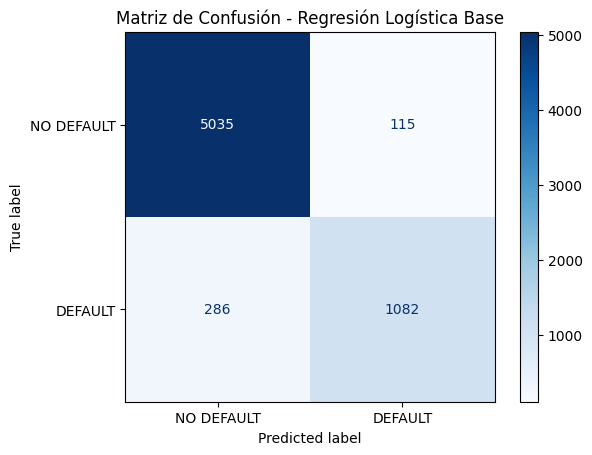

In [64]:
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["NO DEFAULT", "DEFAULT"])
disp.plot(cmap="Blues")
plt.title("Matriz de Confusión - Regresión Logística Base")
plt.show();

In [65]:
# Resumen de los resultados
baseline_results = pd.DataFrame(
    {
        "metric": ["accuracy", "precision_default", "recall_default", "f1_default", "roc_auc"],
        "value": [0.94, 0.90, 0.79, 0.84, 0.9682],
    }
)

baseline_results.T

,0,1,2,3,4
metric,accuracy,precision_default,recall_default,f1_default,roc_auc
value,0.94,0.9,0.79,0.84,0.9682


#### Validación cruzada

In [66]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc",
}

cv_results = cross_validate(model, X, y, cv=cv, scoring=scoring, return_train_score=False)

cv_summary = pd.DataFrame(
    {
        "metric": list(scoring.keys()),
        "mean_score": [cv_results[f"test_{m}"].mean() for m in scoring.keys()],
        "std_score": [cv_results[f"test_{m}"].std() for m in scoring.keys()],
    }
)

cv_summary

,metric,mean_score,std_score
0,accuracy,0.935524,0.004192
1,precision,0.895186,0.018515
2,recall,0.785234,0.015019
3,f1,0.836408,0.010340
4,roc_auc,0.964963,0.005618


#### Validación Cruzada

Se aplicó validación cruzada estratificada de 5 folds con el objetivo de evaluar la estabilidad del modelo.

Los resultados muestran una baja desviación estándar en todas las métricas, lo que indica que el modelo es consistente y no depende de una partición específica de los datos.

Asimismo, las métricas obtenidas son coherentes con las observadas en el conjunto de prueba, lo que sugiere que no existe overfitting y que el modelo generaliza adecuadamente.

En particular, el recall para la clase de default se mantiene cercano al 78%, lo que implica que el modelo logra identificar una proporción significativa de clientes en riesgo, aunque todavía existe margen de mejora en la detección completa de incumplimientos.

#### GridSearch CV

In [67]:
param_grid = {
    "classifier__C": [0.01, 0.1, 1, 10],
    "classifier__class_weight": [None, "balanced"],
    "classifier__solver": ["lbfgs", "liblinear"],
}

grid_search = GridSearchCV(estimator=model, param_grid=param_grid, cv=cv, scoring="f1", n_jobs=-1)

grid_search.fit(X_train, y_train)

print("Best params:", grid_search.best_params_)
print("Best CV score:", grid_search.best_score_)

Best params: {'classifier__C': 10, 'classifier__class_weight': None, 'classifier__solver': 'liblinear'}
Best CV score: 0.8365712994344493


#### Búsqueda de Hiperparámetros

Se realizó una búsqueda de hiperparámetros mediante `GridSearchCV` sobre el modelo de regresión logística.

Se exploraron distintas configuraciones de:
- `C`: intensidad de regularización
- `class_weight`: balanceo de clases
- `solver`: algoritmo de optimización

El criterio principal de selección fue el F1-score, dado que el problema presenta desbalance de clases y resulta importante equilibrar precisión y recall en la detección de defaults.

Los resultados mostraron que el ajuste de hiperparámetros no produjo mejoras significativas frente al modelo base, lo que sugiere que la regresión logística ya se encontraba cerca de su mejor desempeño para este dataset.

* Evaluamos el mejor modelo

In [68]:
best_model = grid_search.best_estimator_

y_pred_best = best_model.predict(X_test)
y_pred_proba_best = best_model.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred_best))
print("ROC-AUC:", roc_auc_score(y_test, y_pred_proba_best))

              precision    recall  f1-score   support

           0       0.95      0.98      0.96      5150
           1       0.90      0.79      0.84      1368

    accuracy                           0.94      6518
   macro avg       0.92      0.88      0.90      6518
weighted avg       0.94      0.94      0.94      6518

ROC-AUC: 0.968243626866519


#### Comparativa clara 

In [70]:
comparison = pd.DataFrame(
    {
        "model": ["Logistic Base", "Logistic Tuned", "PyTorch MLP"],
        "precision_default": [0.90, 0.9, 0.95],
        "recall_default": [0.79, 0.79, 0.87],
        "f1_default": [0.84, 0.84, 0.91],
        "roc_auc": [0.9682, 0.9682, 0.986],
    }
)

comparison

,model,precision_default,recall_default,f1_default,roc_auc
0,Logistic Base,0.90,0.79,0.84,0.9682
1,Logistic Tuned,0.90,0.79,0.84,0.9682
2,PyTorch MLP,0.95,0.87,0.91,0.9860


## Análisis de Hiperparámetros

Tras aplicar búsqueda de hiperparámetros mediante GridSearchCV, no se observaron mejoras significativas en el desempeño del modelo en comparación con el baseline.

Esto sugiere que la regresión logística ya se encontraba en una configuración cercana al óptimo para este conjunto de datos.

Asimismo, indica que la relación entre variables y la variable objetivo presenta una estructura relativamente lineal, permitiendo que un modelo simple capture adecuadamente el patrón de comportamiento.

Por lo tanto, las mejoras adicionales podrían requerir modelos más complejos o enfoques distintos, más allá del ajuste fino de hiperparámetros.